In [1]:
!pip install -q ultralytics easyocr kagglehub
import os, glob, shutil, random, xml.etree.ElementTree as ET
import cv2, numpy as np, torch
from ultralytics import YOLO
import easyocr
print("GPU available:", torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 88.7 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires n

In [2]:
import kagglehub
src = kagglehub.dataset_download("andrewmvd/car-plate-detection")
print("Dataset:", src)               # contains /images and /annotations (VOC XML)
IMAGES = os.path.join(src, "images")
ANNOTS = os.path.join(src, "annotations")

Dataset: /kaggle/input/datasets/andrewmvd/car-plate-detection


In [3]:
ROOT = "/kaggle/working/data"
for sub in ["images/train","images/val","labels/train","labels/val"]:
    os.makedirs(f"{ROOT}/{sub}", exist_ok=True)

def voc_to_yolo(xml_path):
    t = ET.parse(xml_path).getroot()
    W = int(t.find("size/width").text); H = int(t.find("size/height").text)
    rows = []
    for obj in t.findall("object"):
        b = obj.find("bndbox")
        x1,y1,x2,y2 = (float(b.find(k).text) for k in ["xmin","ymin","xmax","ymax"])
        xc,yc = ((x1+x2)/2)/W, ((y1+y2)/2)/H
        bw,bh = (x2-x1)/W, (y2-y1)/H
        rows.append(f"0 {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")
    return rows

xmls = sorted(glob.glob(f"{ANNOTS}/*.xml"))
random.seed(42); random.shuffle(xmls)
split = int(0.8 * len(xmls))

for i, xml in enumerate(xmls):
    part = "train" if i < split else "val"
    name = os.path.splitext(os.path.basename(xml))[0]
    img = os.path.join(IMAGES, name + ".png")
    if not os.path.exists(img): img = os.path.join(IMAGES, name + ".jpg")
    shutil.copy(img, f"{ROOT}/images/{part}/{os.path.basename(img)}")
    with open(f"{ROOT}/labels/{part}/{name}.txt", "w") as f:
        f.write("\n".join(voc_to_yolo(xml)))

print("Train:", split, "Val:", len(xmls)-split)

Train: 346 Val: 87


In [4]:
yaml_txt = f"""path: {ROOT}
train: images/train
val: images/val
nc: 1
names: ['license_plate']
"""
with open(f"{ROOT}/plate.yaml","w") as f: f.write(yaml_txt)
print(yaml_txt)

path: /kaggle/working/data
train: images/train
val: images/val
nc: 1
names: ['license_plate']



In [5]:
model = YOLO("yolov8n.pt")          # 'n' = fast; use 'yolov8s.pt' for better accuracy
results = model.train(
    data=f"{ROOT}/plate.yaml",
    epochs=100, imgsz=640, batch=16,
    patience=20, device=0,
    project="/kaggle/working/runs", name="plate_det"
)
best = "/kaggle/working/runs/plate_det/weights/best.pt"
print("Best weights:", best)

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data/plate.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plate_det, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

In [6]:
detector = YOLO(best)
reader = easyocr.Reader(['en'], gpu=True)

In [7]:
def preprocess_plate(crop):
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    gray = cv2.bilateralFilter(gray, 11, 17, 17)
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return th

def recognize_plate(img_path, conf=0.25):
    img = cv2.imread(img_path)
    dets = detector(img, conf=conf, verbose=False)[0]
    out = []
    for box in dets.boxes:
        x1,y1,x2,y2 = map(int, box.xyxy[0])
        crop = img[y1:y2, x1:x2]
        if crop.size == 0: continue
        proc = preprocess_plate(crop)
        texts = reader.readtext(proc, detail=0)
        plate = "".join(texts).upper().replace(" ", "")
        plate = "".join(ch for ch in plate if ch.isalnum())   # clean
        out.append({"box": (x1,y1,x2,y2), "conf": float(box.conf[0]), "text": plate})
    return img, out

# Try it on a validation image
test_img = glob.glob(f"{ROOT}/images/val/*")[0]
img, results = recognize_plate(test_img)
print(results)

[{'box': (197, 140, 244, 153), 'conf': 0.8143789172172546, 'text': 'KWID'}]


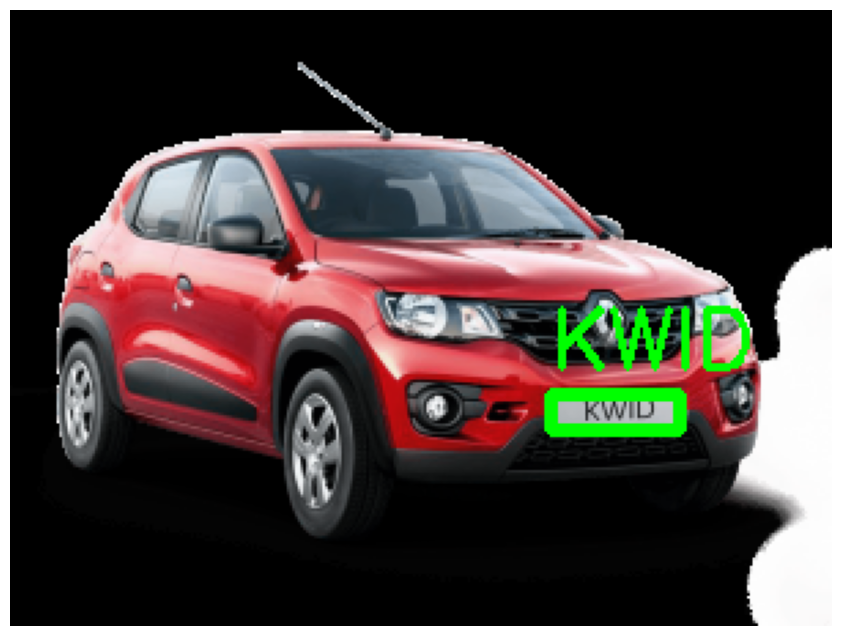

In [8]:
import matplotlib.pyplot as plt
for r in results:
    x1,y1,x2,y2 = r["box"]
    cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),3)
    cv2.putText(img, r["text"], (x1,y1-10), cv2.FONT_HERSHEY_SIMPLEX, 1,(0,255,0),2)
plt.figure(figsize=(12,8)); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()

In [9]:
metrics = detector.val(data=f"{ROOT}/plate.yaml")
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp, "Recall:", metrics.box.mr)

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2728.4±718.6 MB/s, size: 357.2 KB)
val: Scanning /kaggle/working/data/labels/val.cache... 87 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 87/87 45.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.6it/s 2.3s0.3s
                   all         87         97      0.923      0.862       0.93      0.516
Speed: 4.0ms preprocess, 7.9ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
mAP50: 0.9304211237945855
mAP50-95: 0.5156269327402849
Precision: 0.9227445776687523 Recall: 0.8619706790973204


In [10]:
shutil.copy(best, "/kaggle/working/plate_detector.pt")
print("Saved model to /kaggle/working/plate_detector.pt  — download from the Output panel.")

Saved model to /kaggle/working/plate_detector.pt  — download from the Output panel.
